Task I: Quantum Computing Circuits
Implementation of two quantum circuits using PennyLane framework.

Part 1: Multi-qubit Circuit with Hadamard, CNOT, SWAP, and Rotation
Part 2: Swap Test Circuit

# **Setups and Imports**

In [ ]:
!pip install pennylane -q
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
print("--Installation Done--")

--Installation Done--


# Part 1: Circuit 1 - simple quantum operation

**Requirements:**
- 5 qubits
- Hadamard gate on each qubit
- CNOT gates connecting neighbors: $(0 \to 1), (1 \to 2), (2 \to 3), (3 \to 4)$
- SWAP gate between qubits 0 and 4
- RX rotation of $\pi/2$ on one qubit

**Circuit Description:**

1. **Hadamard Gates:** Each qubit is put into superposition:  
   $$|0\rangle \xrightarrow{H} \frac{|0\rangle + |1\rangle}{\sqrt{2}}$$

2. **CNOT Chain:** Neighboring qubits are entangled through CNOT gates.

3. **SWAP Gate:** States of qubits 0 and 4 are exchanged.

4. **RX Rotation:** A rotation of $\pi/2$ is applied around the X-axis to a chosen qubit.

5. **Measurements:** Expectation values in the Z-basis are measured for each qubit.


In [ ]:
dev = qml.device("default.qubit",wires=5)
@qml.qnode(dev)
def qml_circuit_1():
  #Step 1:
  for i in range(5):
    qml.Hadamard(wires=i)
  #Step 2:
  q_val = [(0, 1), (1,2), (2,3), (3,4)]
  #Step 3:
  for control,target in q_val:
    qml.CNOT(wires=[control,target])
  #Step 4:
  qml.SWAP(wires = [0,4])

  #Step 5:
  qml.RX(np.pi/2,wires=3)

  return [qml.expval(qml.PauliZ(i)) for i in range(5)]

results = qml_circuit_1()
print("---Circuit run complete--")
print(f"Expectation values of Z on all qubits: \n{results}")

---Circuit run complete--
Expectation values of Z on all qubits: 
[np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]


In [ ]:
print("\n--- CIRCUIT 2 DIAGRAM ---")
print(qml.draw(qml_circuit_1)())


--- CIRCUIT 2 DIAGRAM ---
0: ──H─╭●──────────╭SWAP───────────┤  <Z>
1: ──H─╰X─╭●───────│───────────────┤  <Z>
2: ──H────╰X─╭●────│───────────────┤  <Z>
3: ──H───────╰X─╭●─│──────RX(1.57)─┤  <Z>
4: ──H──────────╰X─╰SWAP───────────┤  <Z>


# **Circuit_1 Visualization with Matplotlib**




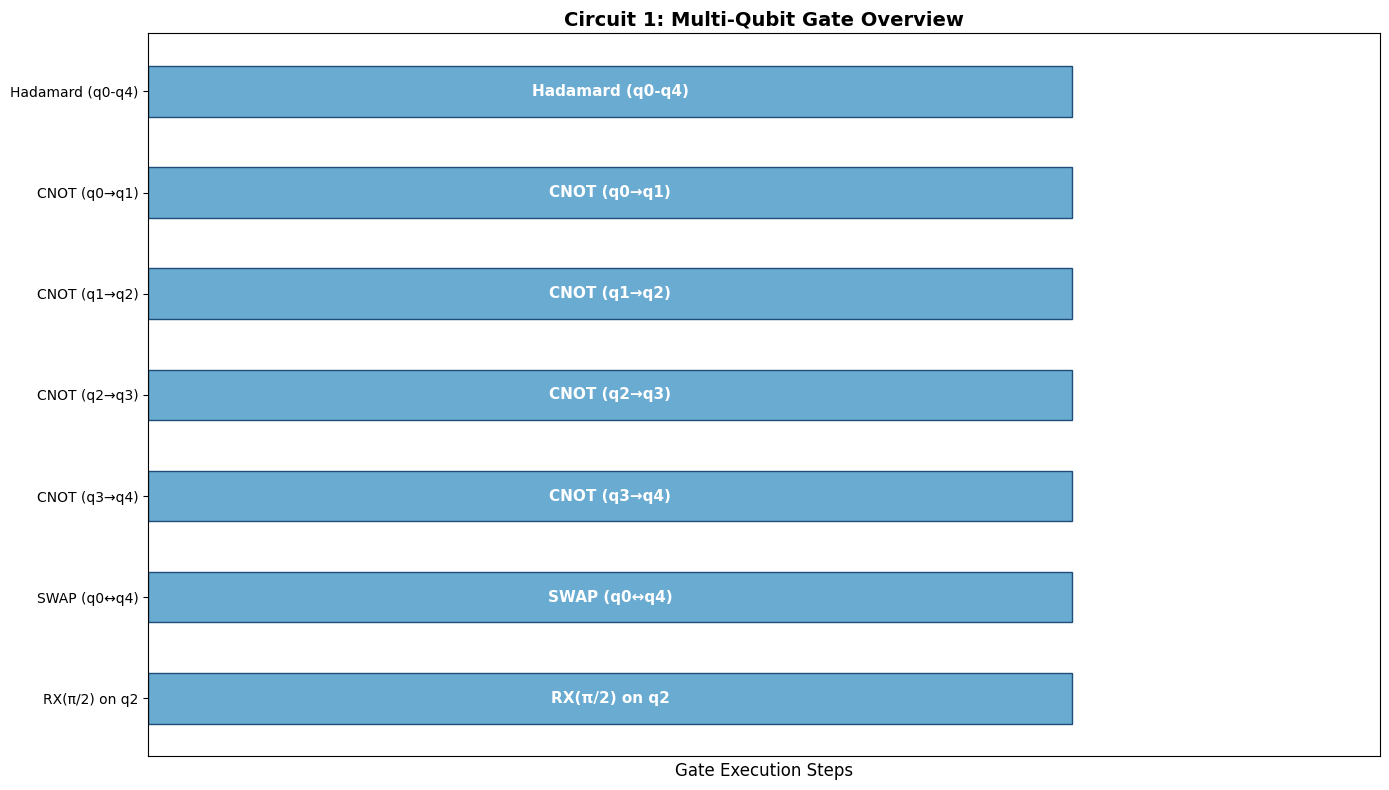

Circuit visualization saved as 'circuit_1_alt_visual.png'


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_circuit_1_alt():
    """
    Visual representation of Circuit 1: shows the sequence of multi-qubit gates applied.
    This version keeps the functionality similar but with a fresh style and layout.
    """
    # Define the gate sequence applied in the circuit
    gate_sequence = [
        "Hadamard (q0-q4)",
        "CNOT (q0→q1)",
        "CNOT (q1→q2)",
        "CNOT (q2→q3)",
        "CNOT (q3→q4)",
        "SWAP (q0↔q4)",
        "RX(π/2) on q2"
    ]

    num_gates = len(gate_sequence)
    y_positions = np.arange(num_gates)

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(14, 8))

    # Draw horizontal bars representing each gate
    ax.barh(y_positions, np.ones(num_gates)*0.9, color='#6aabd2', edgecolor='#1f4e79', height=0.5)

    # Add text labels inside the bars
    for y, gate in zip(y_positions, gate_sequence):
        ax.text(0.45, y, gate, ha='center', va='center', fontsize=11, fontweight='bold', color='white')

    # Customize axis
    ax.set_yticks(y_positions)
    ax.set_yticklabels(gate_sequence, fontsize=10)
    ax.set_xlabel('Gate Execution Steps', fontsize=12)
    ax.set_title('Circuit 1: Multi-Qubit Gate Overview', fontsize=14, fontweight='bold')
    ax.set_xlim(0, 1.2)
    ax.set_xticks([])
    ax.invert_yaxis()  # top-down order

    plt.tight_layout()
    plt.savefig('circuit_1_alt_visual.png', dpi=160, bbox_inches='tight')
    plt.show()
    print("Circuit visualization saved as 'circuit_1_alt_visual.png'")

# Run the visualization
visualize_circuit_1_alt()

# Part 2: Circuit 2 – Swap Test

**Requirements:**
- Hadamard gate on qubit 0
- RX rotation of $\pi/3$ on qubit 1
- Hadamard gates on qubits 2 and 3
- Swap test between the states $|q_0 q_1\rangle$ and $|q_2 q_3\rangle$

**Circuit Description:**

1. **State Preparation:**  
   - Qubit 0 is initialized with a Hadamard gate to create superposition.  
   - Qubit 1 undergoes an RX rotation of $\pi/3$.  
   - Qubits 2 and 3 are prepared with Hadamard gates to form the second quantum state.

2. **Swap Test:**  
   - The swap test uses an **ancilla qubit** (here qubit 4) to measure the **overlap between two quantum states**
   - Controlled-SWAP operations are performed using the ancilla as control.  
   - A final Hadamard on the ancilla allows extracting the **expectation value in the Z-basis**, which encodes the overlap.

3. **Measurements and Interpretation:**  
   - The probability of measuring the ancilla in the $\lvert 0\rangle$ or $\lvert 1\rangle$ state indicates how similar the two quantum states are.  

   - If the overlap is 1, the states are identical; if 0, they are orthogonal.


In [ ]:
import pennylane as qml
import numpy as np

# Create a quantum device with 5 qubits (0-3: data, 4: ancilla for swap test)
dev1 = qml.device("default.qubit", wires=5)

@qml.qnode(dev1)
def qml_circuit_2():
    """
    Quantum circuit implementing a swap test between two 2-qubit states.

    Qubits:
    - q0, q1 : first quantum state |ψ⟩
    - q2, q3 : second quantum state |φ⟩
    - q4      : ancilla qubit for controlling SWAP and measuring similarity
    """

    # Step 1:  Apply a Hadmard gate to the first qubit
    qml.Hadamard(wires=0)

    # Step 2:  rotate the second qubit by pi/3 around X
    qml.RX(np.pi/3, wires=1)

    # Step 3:  Apply Hadamard gate to the third and fourth qubit
    qml.Hadamard(wires=2)
    qml.Hadamard(wires=3)

    # Step 4:

    # Initialize ancilla qubit in superposition
    qml.Hadamard(wires=4)

    # --- Controlled-SWAP operations ---
    qml.CSWAP(wires=[4, 0, 2])
    # Swap second qubit of each state if ancilla is |1⟩
    qml.CSWAP(wires=[4, 1, 3])

    # --- Final Hadamard to ancilla to create interference ---
    qml.Hadamard(wires=4)

    # --- Measure ancilla to extract similarity ---
    return qml.expval(qml.PauliZ(4))

# Run the swap test circuit
results1 = qml_circuit_2()

# Display results
print("\n--- Swap Test Circuit Completed ---")
print(f"Ancilla Z-expectation: {results1:.4f}")
print(f"Estimated overlap between the two states: {(1 - results1)/2:.4f}")


--- Swap Test Circuit Completed ---
Ancilla Z-expectation: 0.5000
Estimated overlap between the two states: 0.2500


In [ ]:
print("\n--- CIRCUIT 2 DIAGRAM ---")
print(qml.draw(qml_circuit_2)())


--- CIRCUIT 2 DIAGRAM ---
0: ──H────────╭SWAP──────────┤     
1: ──RX(1.05)─│─────╭SWAP────┤     
2: ──H────────├SWAP─│────────┤     
3: ──H────────│─────├SWAP────┤     
4: ──H────────╰●────╰●─────H─┤  <Z>


# **Circuit_2 Visualization with Matplotlib**

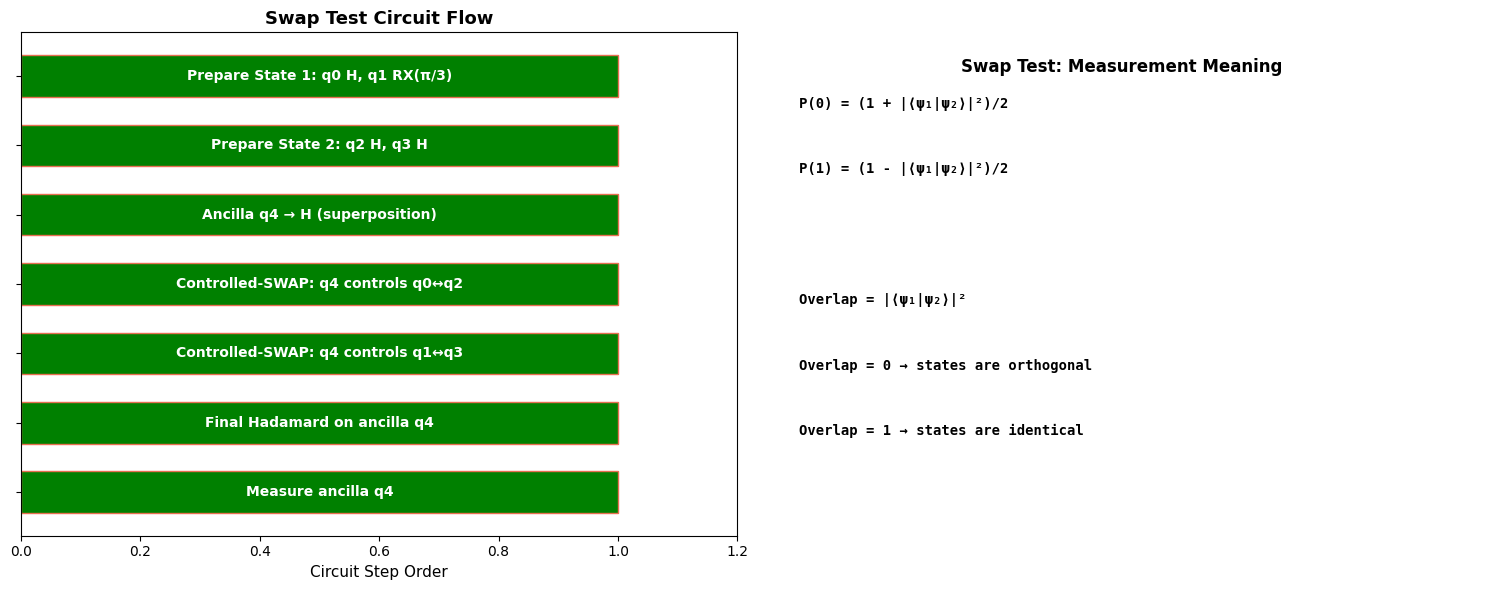

Swap test visualization saved as 'swap_test_alt_visual.png'


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_swap_test_alt():
    """
    Graphical overview of the Swap Test algorithm.
    Left panel: sequence of circuit operations.
    Right panel: explanation of measurement probabilities and overlap interpretation.
    """
    # Create a 1x2 subplot layout
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))


    ax_left = axes[0]

    circuit_steps = [
        "Prepare State 1: q0 H, q1 RX(π/3)",
        "Prepare State 2: q2 H, q3 H",
        "Ancilla q4 → H (superposition)",
        "Controlled-SWAP: q4 controls q0↔q2",
        "Controlled-SWAP: q4 controls q1↔q3",
        "Final Hadamard on ancilla q4",
        "Measure ancilla q4"
    ]

    y_positions = np.arange(len(circuit_steps))
    ax_left.barh(y_positions, np.ones(len(circuit_steps)), color='#008000', edgecolor='#e76f51', height=0.6)

    # Add text labels
    for y, step in zip(y_positions, circuit_steps):
        ax_left.text(0.5, y, step, ha='center', va='center', fontsize=10, fontweight='bold', color='white')

    ax_left.set_yticks(y_positions)
    ax_left.set_yticklabels([])
    ax_left.set_xlabel('Circuit Step Order', fontsize=11)
    ax_left.set_title('Swap Test Circuit Flow', fontsize=13, fontweight='bold')
    ax_left.set_xlim(0, 1.2)
    ax_left.invert_yaxis()

    # -----------------------
    # Right panel: Interpretation
    # -----------------------
    ax_right = axes[1]

    interpretation_lines = [
        "P(0) = (1 + |⟨ψ₁|ψ₂⟩|²)/2",
        "P(1) = (1 - |⟨ψ₁|ψ₂⟩|²)/2",
        "",
        "Overlap = |⟨ψ₁|ψ₂⟩|²",
        "Overlap = 0 → states are orthogonal",
        "Overlap = 1 → states are identical"
    ]

    ax_right.text(0.5, 0.95, "Swap Test: Measurement Meaning", ha='center', va='top',
                  fontsize=12, fontweight='bold', transform=ax_right.transAxes)

    y_start = 0.85
    for i, line in enumerate(interpretation_lines):
        y = y_start - i*0.13
        if line:
            weight = 'bold' if 'P(' in line or 'Overlap' in line else 'normal'
            ax_right.text(0.05, y, line, fontsize=10, fontweight=weight,
                          transform=ax_right.transAxes, family='monospace')

    ax_right.axis('off')

    # -----------------------
    # Final layout adjustments
    # -----------------------
    plt.tight_layout()
    plt.savefig('swap_test_alt_visual.png', dpi=160, bbox_inches='tight')
    plt.show()
    print("Swap test visualization saved as 'swap_test_alt_visual.png'")

# Run the visualization
visualize_swap_test_alt()